# Задания

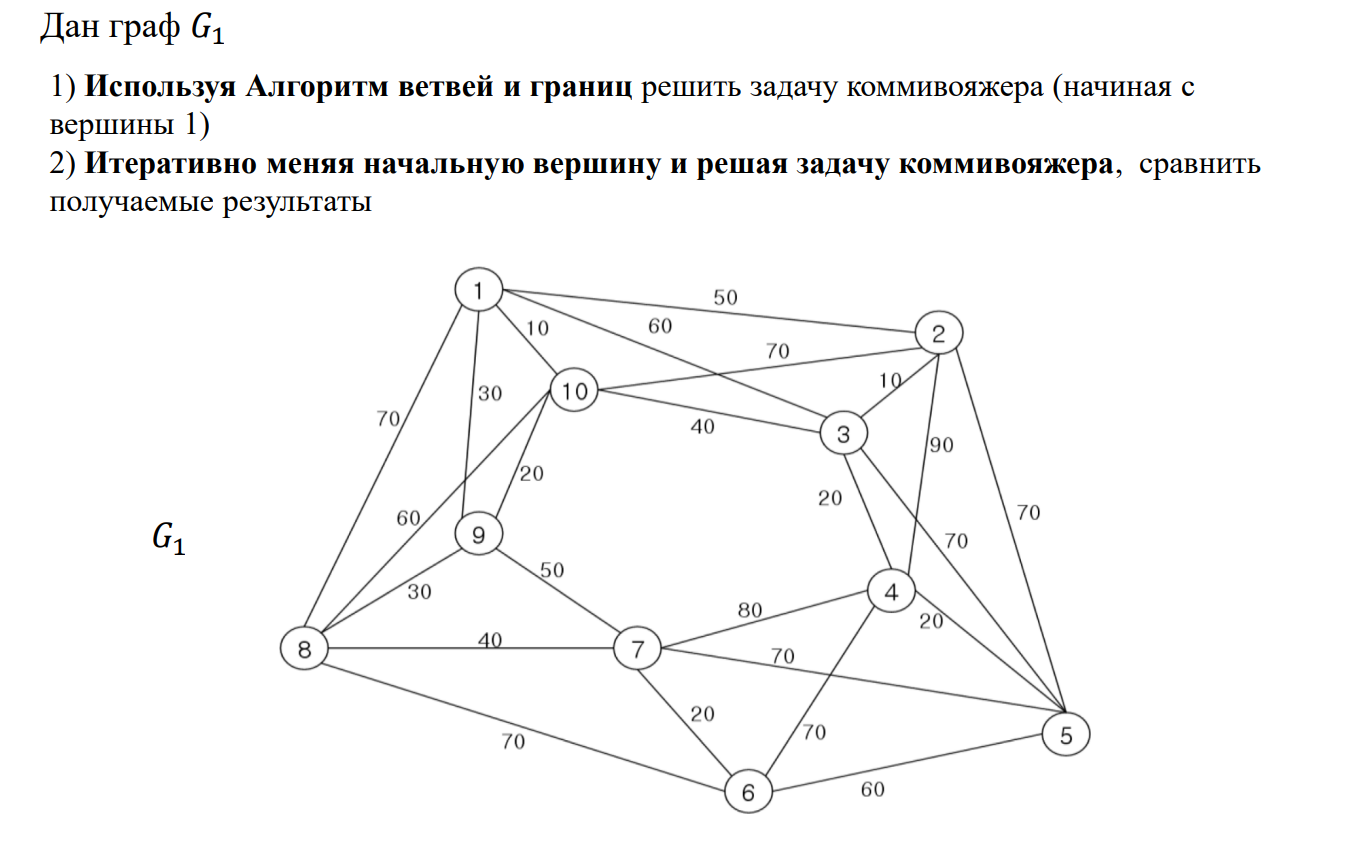

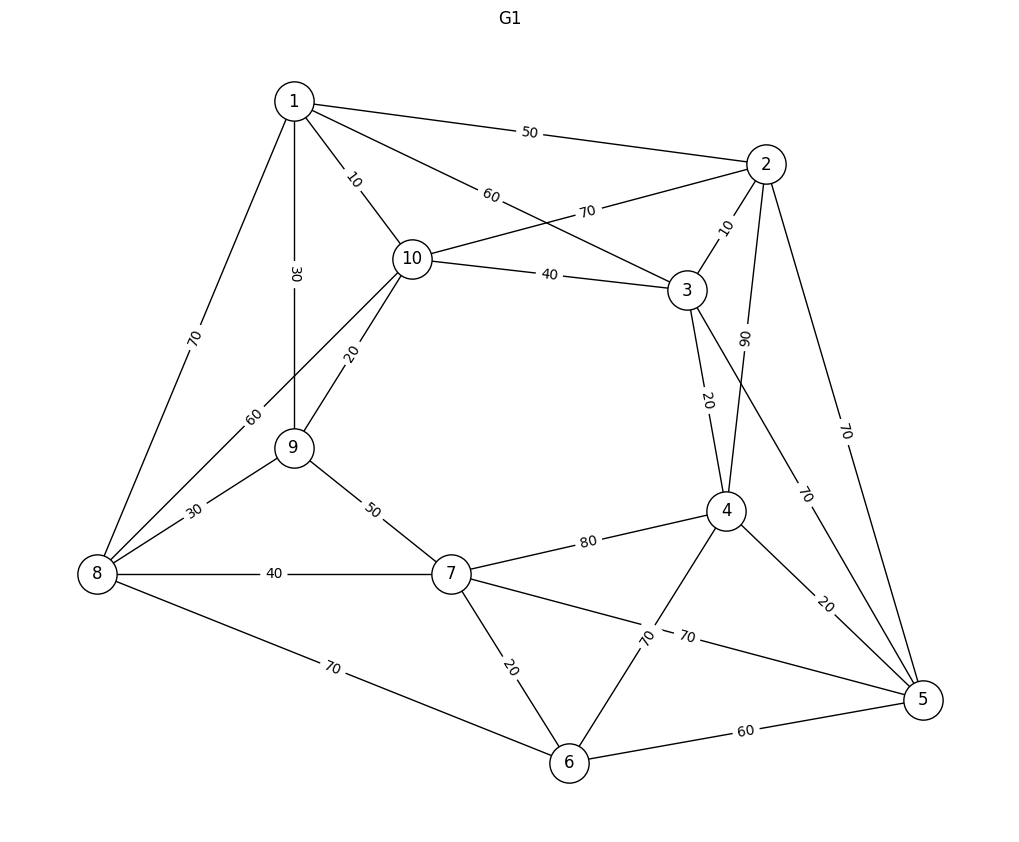

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx

E =[
    (1, 2, 50), (1, 3, 60), (1, 8, 70), (1, 9, 30), (1, 10, 10),
    (2, 3, 10), (2, 4, 90), (2, 5, 70), (2, 10, 70),
    (3, 4, 20), (3, 5, 70), (3, 10, 40),
    (4, 5, 20), (4, 6, 70), (4, 7, 80),
    (5, 6, 60), (5, 7, 70),
    (6, 7, 20), (6, 8, 70),
    (7, 8, 40), (7, 9, 50),
    (8, 9, 30), (8, 10, 60),
    (9, 10, 20)
]

P = {
    1: (30, 90), 2: (90, 80), 3: (80, 60), 4: (85, 25), 
    5: (110, -5), 6: (65, -15), 7: (50, 15), 8: (5, 15), 
    9: (30, 35), 10: (45, 65)
}

G = nx.Graph()
for u, v, w in E:
    G.add_edge(u, v, w=w)

plt.figure(figsize=(10, 8))
nx.draw(G, P, with_labels=True, node_color='white', edgecolors='black', node_size=800)
L = nx.get_edge_attributes(G, 'w')
nx.draw_networkx_edge_labels(G, P, edge_labels=L)
plt.title("G1")
plt.show()

In [2]:
N = 10
I = np.inf
M = {i: {j: I for j in range(1, N+1)} for i in range(1, N+1)}
for u, v, w in E:
    M[u][v] = w
    M[v][u] = w

bc = I
bp =[]

def bb(p, c):
    global bc, bp
    if len(p) == N:
        if M[p[-1]][p[0]] < I:
            if c + M[p[-1]][p[0]] < bc:
                bc = c + M[p[-1]][p[0]]
                bp = p + [p[0]]
        return
    lb = c
    r =[x for x in range(1, N+1) if x not in p]
    if r:
        lb += min(M[p[-1]][x] for x in r)
        for i in r:
            lb += min([M[i][x] for x in r if x != i] + [M[i][p[0]]])
    if lb >= bc: 
        return
    for v in r:
        if M[p[-1]][v] < I:
            bb(p + [v], c + M[p[-1]][v])

bb([1], 0)
print("Минимальная стоимость:", bc)
print("Оптимальный путь:", bp)

Минимальная стоимость: 280
Оптимальный путь: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 1]


In [3]:
R = {}
for s in range(1, N+1):
    bc = I
    bp = []
    bb([s], 0)
    R[s] = (bc, bp)

for s, (c, p) in R.items():
    print(f"Начало: {s} | Стоимость: {c} | Путь: {p}")

print("\nСравнение результатов:")
print("Стоимость оптимального цикла не меняется при смене начальной вершины, так как граф неориентированный.")
print("Изменяется только порядок обхода в полученном цикле.")

Начало: 1 | Стоимость: 280 | Путь: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 1]
Начало: 2 | Стоимость: 280 | Путь: [2, 1, 10, 9, 8, 7, 6, 5, 4, 3, 2]
Начало: 3 | Стоимость: 280 | Путь: [3, 2, 1, 10, 9, 8, 7, 6, 5, 4, 3]
Начало: 4 | Стоимость: 280 | Путь: [4, 3, 2, 1, 10, 9, 8, 7, 6, 5, 4]
Начало: 5 | Стоимость: 280 | Путь: [5, 4, 3, 2, 1, 10, 9, 8, 7, 6, 5]
Начало: 6 | Стоимость: 280 | Путь: [6, 5, 4, 3, 2, 1, 10, 9, 8, 7, 6]
Начало: 7 | Стоимость: 280 | Путь: [7, 6, 5, 4, 3, 2, 1, 10, 9, 8, 7]
Начало: 8 | Стоимость: 280 | Путь: [8, 7, 6, 5, 4, 3, 2, 1, 10, 9, 8]
Начало: 9 | Стоимость: 280 | Путь: [9, 8, 7, 6, 5, 4, 3, 2, 1, 10, 9]
Начало: 10 | Стоимость: 280 | Путь: [10, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10]

Сравнение результатов:
Стоимость оптимального цикла не меняется при смене начальной вершины, так как граф неориентированный.
Изменяется только порядок обхода в полученном цикле.


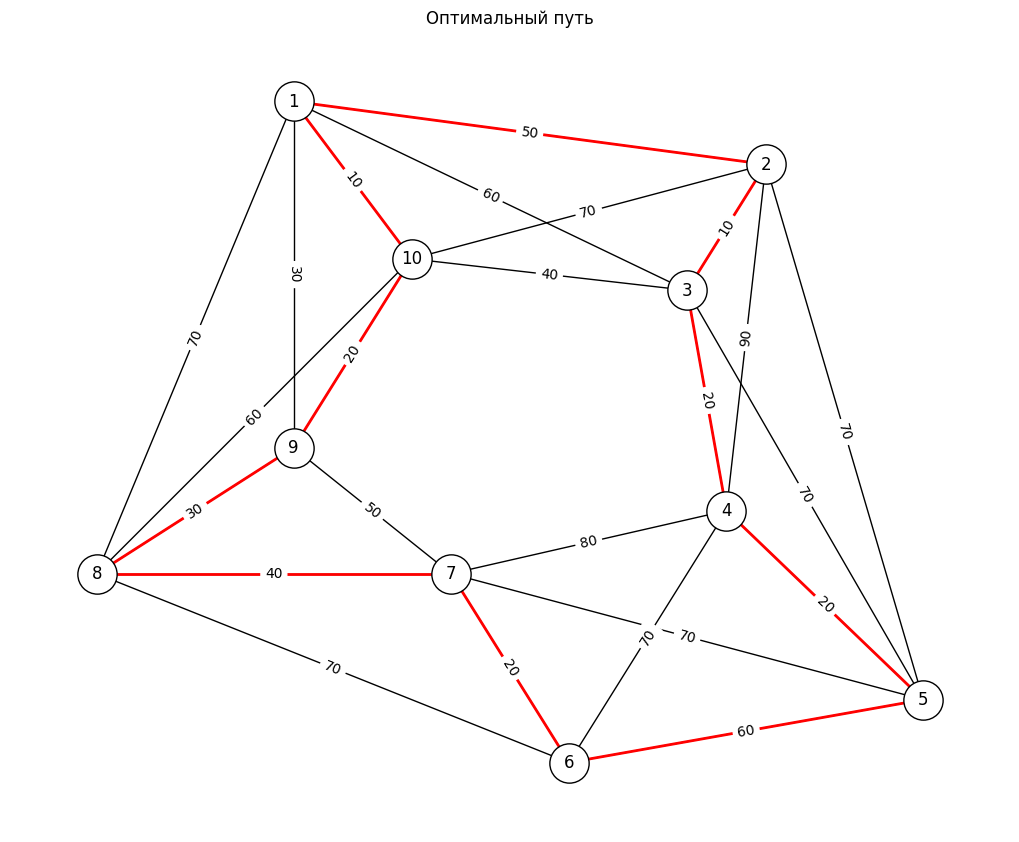

In [4]:
pe = [(bp[i], bp[i+1]) for i in range(len(bp)-1)]

plt.figure(figsize=(10, 8))
nx.draw(G, P, with_labels=True, node_color='white', edgecolors='black', node_size=800)
nx.draw_networkx_edges(G, P, edgelist=pe, edge_color='red', width=2)
nx.draw_networkx_edge_labels(G, P, edge_labels=L)
plt.title("Оптимальный путь")
plt.show()

# Задания для самостоятельной работы

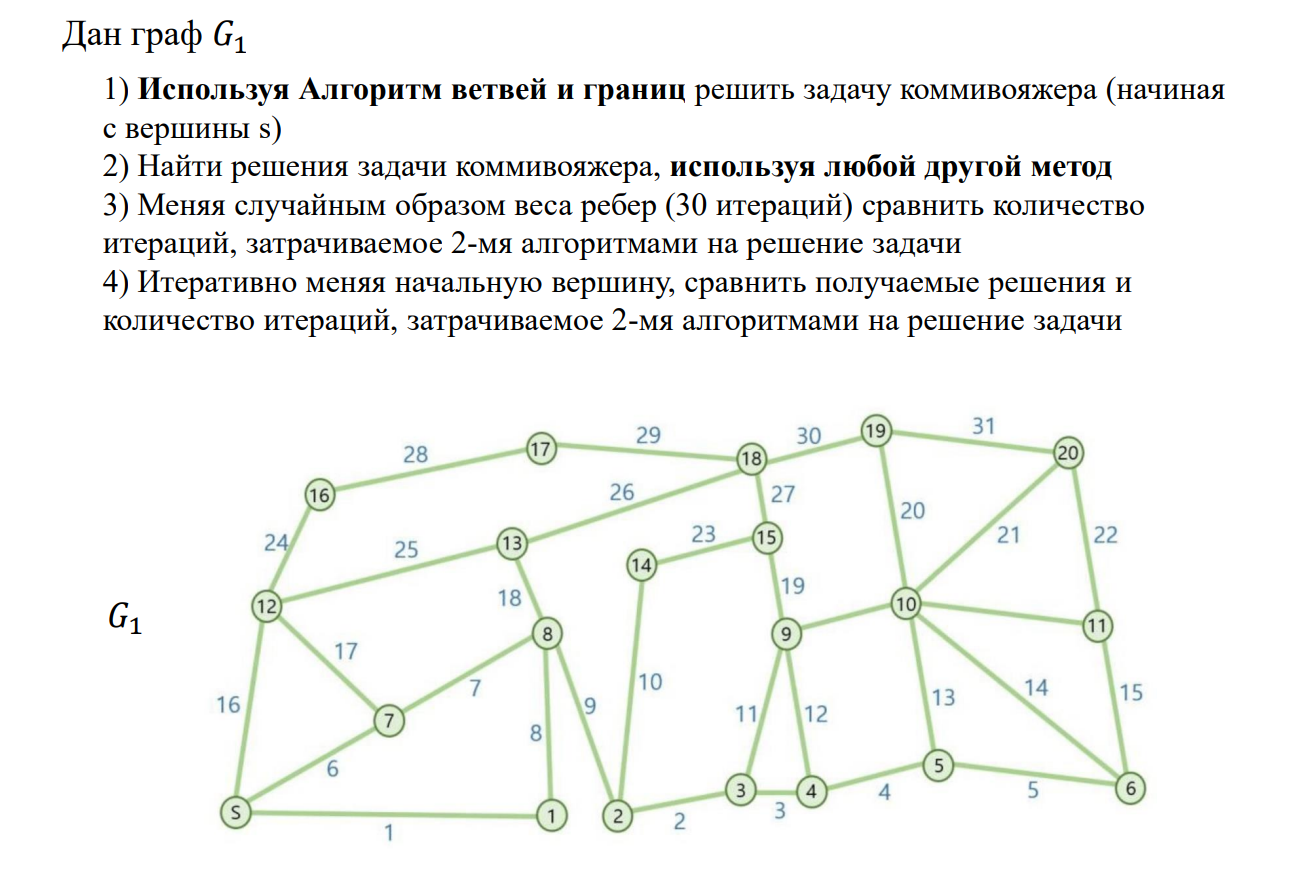

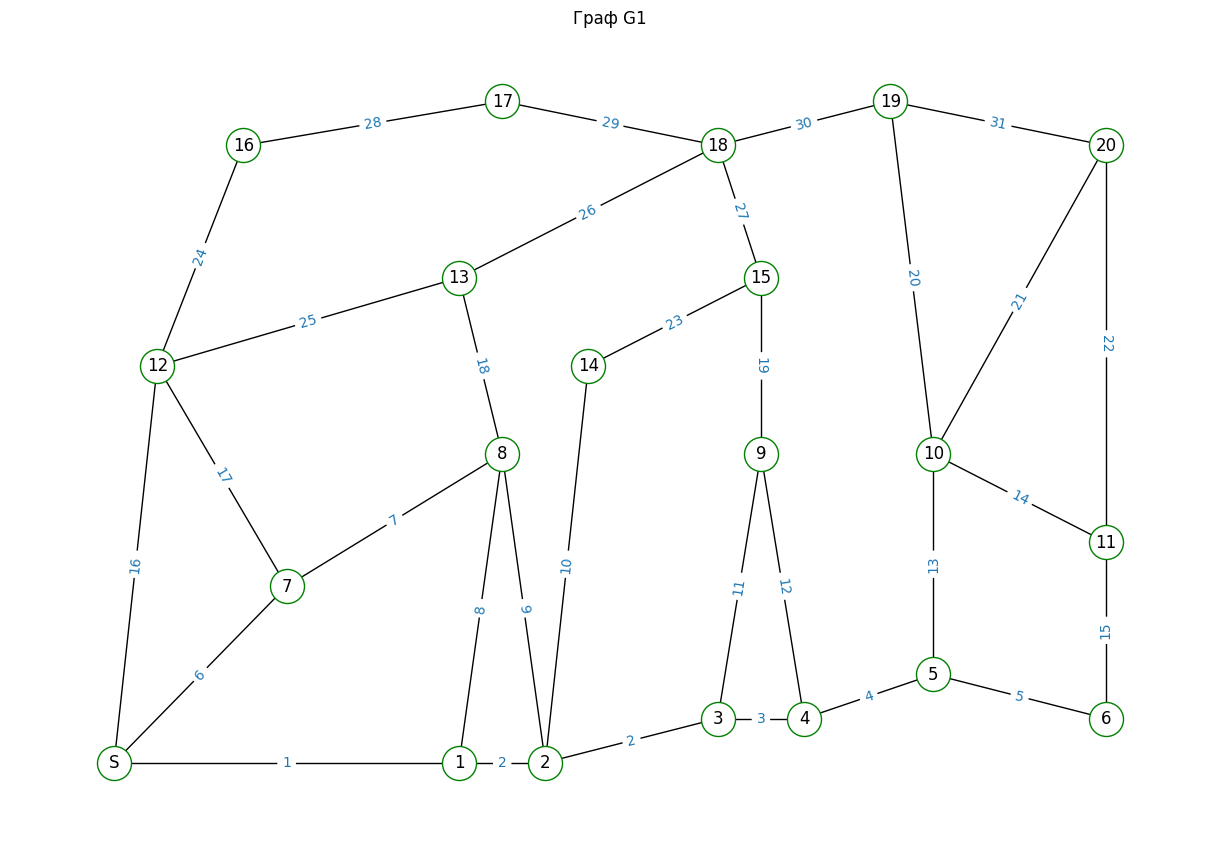

In [19]:
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx

# Подготовка данных графа G1
E = [
    (0, 1, 1), (0, 7, 6), (0, 12, 16), (1, 2, 2), (1, 8, 8),
    (7, 8, 7), (7, 12, 17), (2, 3, 2), (2, 8, 9), (2, 14, 10),
    (8, 13, 18), (12, 13, 25), (12, 16, 24), (16, 17, 28),
    (17, 18, 29), (13, 18, 26), (14, 15, 23), (15, 18, 27),
    (15, 9, 19), (3, 4, 3), (3, 9, 11), (4, 5, 4), (4, 9, 12),
    (5, 6, 5), (5, 10, 13), (6, 11, 15), (11, 10, 14),
    (11, 20, 22), (10, 19, 20), (10, 20, 21), (19, 18, 30),
    (19, 20, 31)
]

P = {
    0: (0, 0), 1: (4, 0), 2: (5, 0), 3: (7, 0.5), 4: (8, 0.5), 
    5: (9.5, 1), 6: (11.5, 0.5), 7: (2, 2), 8: (4.5, 3.5), 
    9: (7.5, 3.5), 10: (9.5, 3.5), 11: (11.5, 2.5), 12: (0.5, 4.5), 
    13: (4, 5.5), 14: (5.5, 4.5), 15: (7.5, 5.5), 16: (1.5, 7), 
    17: (4.5, 7.5), 18: (7, 7), 19: (9, 7.5), 20: (11.5, 7)
}

G = nx.Graph()
for u, v, w in E:
    G.add_edge(u, v, w=w)

L = {i: str(i) for i in range(1, 21)}
L[0] = 'S'

plt.figure(figsize=(12, 8))
nx.draw(G, P, labels=L, node_color='white', edgecolors='green', node_size=600)
W = nx.get_edge_attributes(G, 'w')
nx.draw_networkx_edge_labels(G, P, edge_labels=W, font_color='tab:blue')
plt.title("Граф G1")
plt.show()

In [26]:
def bg(el):
    g = {i: {} for i in range(21)}
    for u, v, w in el:
        g[u][v] = w
        g[v][u] = w
    return g

gd = bg(E)

def a1(g, s):
    bc = float('inf')
    bp =[]
    it = 0
    adj = {u: sorted(g[u].items(), key=lambda x: x[1]) for u in g}
    mw = {u: min(g[u].values()) for u in g}
    smw = sum(mw.values())
    
    def dfs(c, p, cst, rmw):
        nonlocal bc, bp, it
        it += 1
        if cst + rmw >= bc: return
        if len(p) == len(g):
            if s in g[c]:
                if cst + g[c][s] < bc:
                    bc = cst + g[c][s]
                    bp = p + [s]
            return
        for n, w in adj[c]:
            if n not in p:
                dfs(n, p + [n], cst + w, rmw - mw[n])
                
    dfs(s, [s], 0, smw - mw[s])
    return bc, bp, it

def a2(g, s):
    n = len(g)
    m = {}
    it = 0
    
    def sol(c, msk):
        nonlocal it
        it += 1
        if msk == (1 << n) - 1:
            if s in g[c]: return g[c][s], [s]
            return float('inf'),[]
            
        st = (c, msk)
        if st in m: return m[st]
            
        bc = float('inf')
        bp =[]
        for nx, w in g[c].items():
            if not (msk & (1 << nx)):
                tc, tp = sol(nx, msk | (1 << nx))
                if tc + w < bc:
                    bc = tc + w
                    bp = [nx] + tp
                    
        m[st] = (bc, bp)
        return bc, bp
        
    c, p = sol(s, 1 << s)
    return c, [s] + p, it

c1, p1, i1 = a1(gd, 0)
c2, p2, i2 = a2(gd, 0)
print(c1, p1, i1)
print(c2, p2, i2)

323 [0, 1, 2, 14, 15, 9, 3, 4, 5, 6, 11, 20, 10, 19, 18, 17, 16, 12, 13, 8, 7, 0] 10138
323 [0, 1, 2, 14, 15, 9, 3, 4, 5, 6, 11, 20, 10, 19, 18, 17, 16, 12, 13, 8, 7, 0] 9185


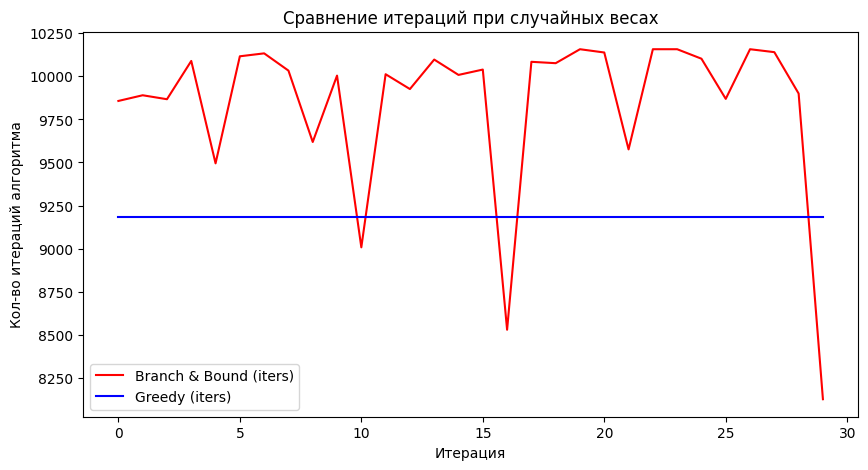

In [27]:
# Сравнение при изменении весов
i1_a, i2_a = [], []
for _ in range(30):
    er = [(u, v, np.random.randint(1, 50)) for u, v, w in E]
    gr = bg(er)
    _, _, t1 = a1(gr, 0)
    _, _, t2 = a2(gr, 0)
    i1_a.append(t1)
    i2_a.append(t2)

plt.figure(figsize=(10, 5))
plt.plot(i1_a, label="Branch & Bound (iters)", color='red')
plt.plot(i2_a, label="Greedy (iters)", color='blue')
plt.legend()
plt.title("Сравнение итераций при случайных весах")
plt.xlabel("Итерация")
plt.ylabel("Кол-во итераций алгоритма")
plt.show()

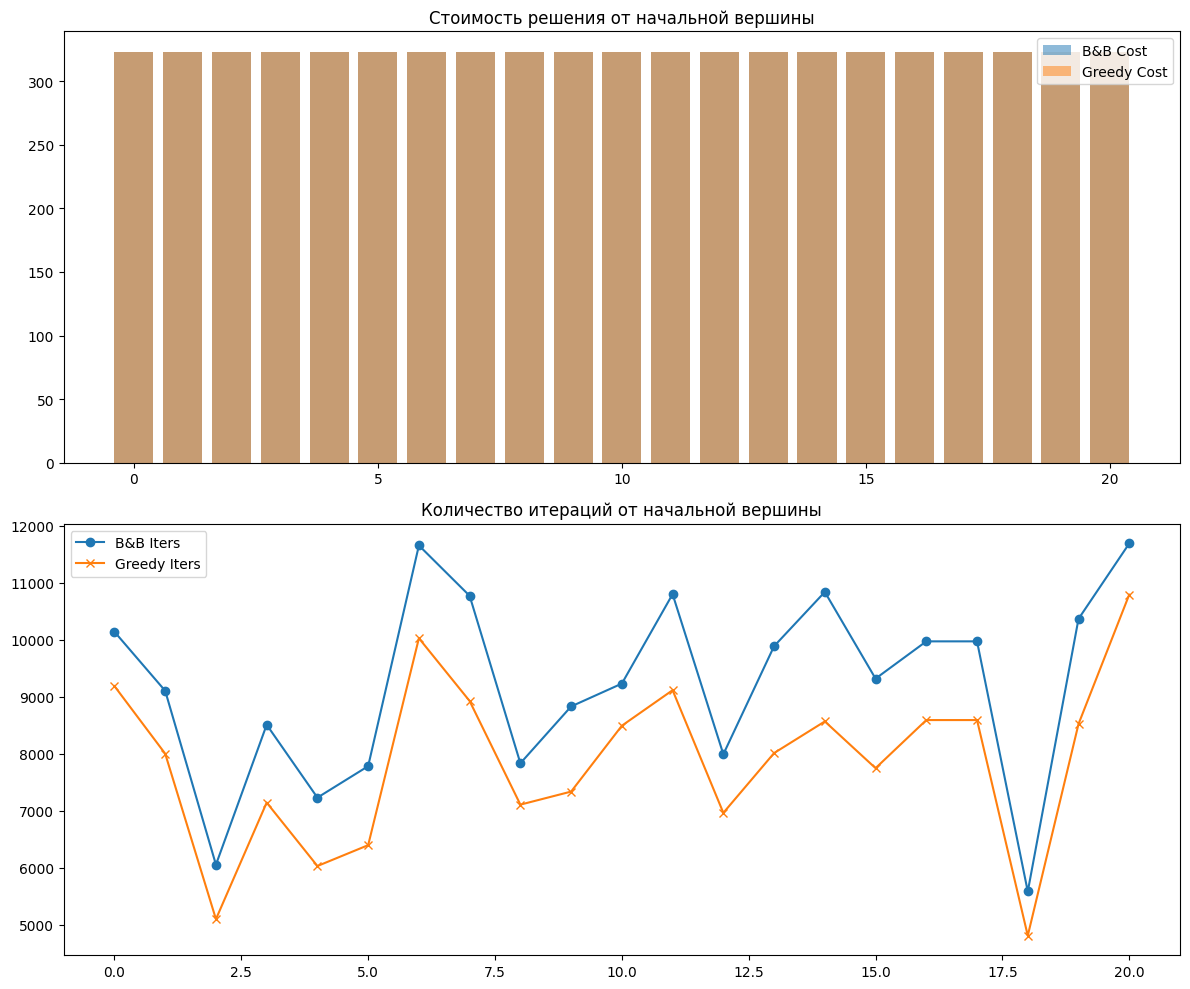

In [28]:
# Сравнение при изменении начальной вершины
c1_n, c2_n = [], []
i1_n, i2_n = [], []
nds = list(range(21))

for s in nds:
    v1, _, t1 = a1(gd, s)
    v2, _, t2 = a2(gd, s)
    c1_n.append(v1 if v1 != float('inf') else 0)
    c2_n.append(v2 if v2 != float('inf') else 0)
    i1_n.append(t1)
    i2_n.append(t2)

fig, ax = plt.subplots(2, 1, figsize=(12, 10))
ax[0].bar(nds, c1_n, alpha=0.5, label='B&B Cost')
ax[0].bar(nds, c2_n, alpha=0.5, label='Greedy Cost')
ax[0].set_title("Стоимость решения от начальной вершины")
ax[0].legend()

ax[1].plot(nds, i1_n, label='B&B Iters', marker='o')
ax[1].plot(nds, i2_n, label='Greedy Iters', marker='x')
ax[1].set_title("Количество итераций от начальной вершины")
ax[1].legend()
plt.tight_layout()
plt.show()